In [15]:
# =========================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# =========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [20]:
# =========================================
# 2. CARREGAMENTO DOS DADOS
# =========================================

colunas = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education-num',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'native-country',
    'income'
]

df = pd.read_csv(
    "adult.data",
    names=colunas
)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [21]:
# =========================================
# 3. PRÉ-PROCESSAMENTO
# =========================================

# Remover espaços extras
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Substituir ? por NaN
df.replace('?', np.nan, inplace=True)

# Remover valores ausentes
df.dropna(inplace=True)

# Transformar variáveis categóricas em numéricas
le = LabelEncoder()

for coluna in df.select_dtypes(include='object').columns:
    df[coluna] = le.fit_transform(df[coluna])

df.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11544\1612899511.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for coluna in df.select_dtypes(include='object').columns:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,0


In [22]:
# =========================================
# 4. SEPARAÇÃO DOS DADOS
# =========================================

X = df.drop('income', axis=1)
y = df['income']

# Divisão treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Padronização dos dados
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
# =========================================
# 5. MODELO KNN
# =========================================

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

y_prob_knn = knn.predict_proba(X_test)[:,1]

In [24]:
# Métricas KNN

print("===== KNN =====")

print("Acurácia:", accuracy_score(y_test, y_pred_knn))
print("Precisão:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-Score:", f1_score(y_test, y_pred_knn))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

===== KNN =====
Acurácia: 0.8283345275872659
Precisão: 0.6598768356229275
Recall: 0.5922619047619048
F1-Score: 0.6242437822092762

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.90      0.89      7417
           1       0.66      0.59      0.62      2352

    accuracy                           0.83      9769
   macro avg       0.77      0.75      0.76      9769
weighted avg       0.82      0.83      0.83      9769



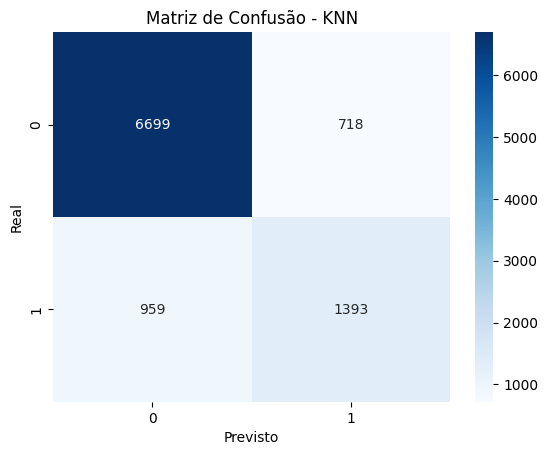

In [25]:
# Matriz de confusão KNN

cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusão - KNN")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

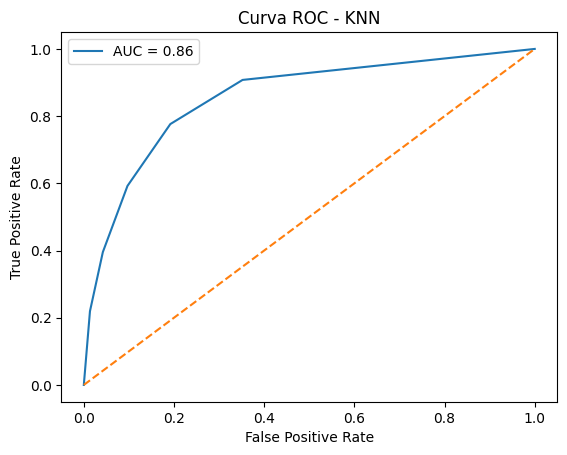

In [26]:
# Curva ROC KNN

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.plot(fpr_knn, tpr_knn, label=f'AUC = {roc_auc_knn:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.title("Curva ROC - KNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [27]:
# =========================================
# 6. MODELO SVM
# =========================================

svm = SVC(
    kernel='rbf',
    probability=True
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

y_prob_svm = svm.predict_proba(X_test)[:,1]

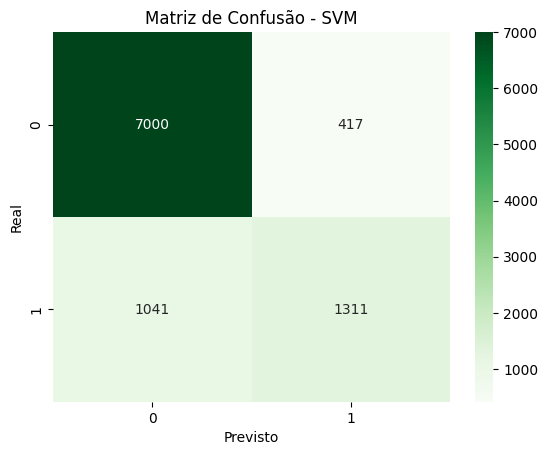

In [28]:
# Matriz de confusão SVM

cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')

plt.title("Matriz de Confusão - SVM")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

In [ ]:
# Curva ROC SVM

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.plot(fpr_svm, tpr_svm, label=f'AUC = {roc_auc_svm:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.title("Curva ROC - SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [30]:
# =========================================
# 7. MODELO ARVORE DE DECISÃO
# =========================================

tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

y_prob_tree = tree.predict_proba(X_test)[:,1]

In [31]:
# Métricas Árvore de Decisão

print("===== DECISION TREE =====")

print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("Precisão:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1-Score:", f1_score(y_test, y_pred_tree))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tree))

===== DECISION TREE =====
Acurácia: 0.8482956290306071
Precisão: 0.7770700636942676
Recall: 0.5187074829931972
F1-Score: 0.6221315655277919

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.91      7417
           1       0.78      0.52      0.62      2352

    accuracy                           0.85      9769
   macro avg       0.82      0.74      0.76      9769
weighted avg       0.84      0.85      0.84      9769



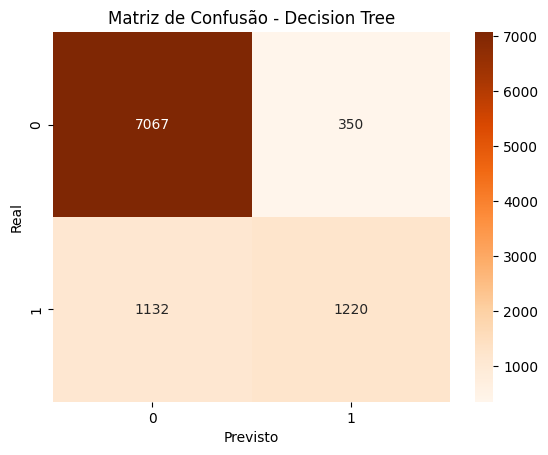

In [32]:
# Matriz de confusão Decision Tree

cm_tree = confusion_matrix(y_test, y_pred_tree)

sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Oranges')

plt.title("Matriz de Confusão - Decision Tree")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

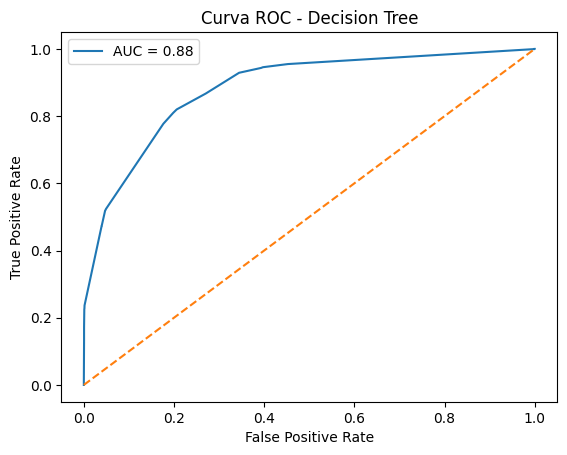

In [33]:
# Curva ROC Decision Tree

fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

roc_auc_tree = auc(fpr_tree, tpr_tree)

plt.plot(fpr_tree, tpr_tree, label=f'AUC = {roc_auc_tree:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.title("Curva ROC - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [34]:
# =========================================
# 8. COMPARAÇÃO DOS MODELOS
# =========================================

resultados = pd.DataFrame({
    'Modelo': ['KNN', 'SVM', 'Decision Tree'],
    
    'Acurácia': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_tree)
    ],
    
    'Precisão': [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_tree)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_tree)
    ],
    
    'F1-Score': [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_tree)
    ]
})

resultados

,Modelo,Acurácia,Precisão,Recall,F1-Score
0,KNN,0.828335,0.659877,0.592262,0.624244
1,SVM,0.850752,0.758681,0.557398,0.642647
2,Decision Tree,0.848296,0.777070,0.518707,0.622132


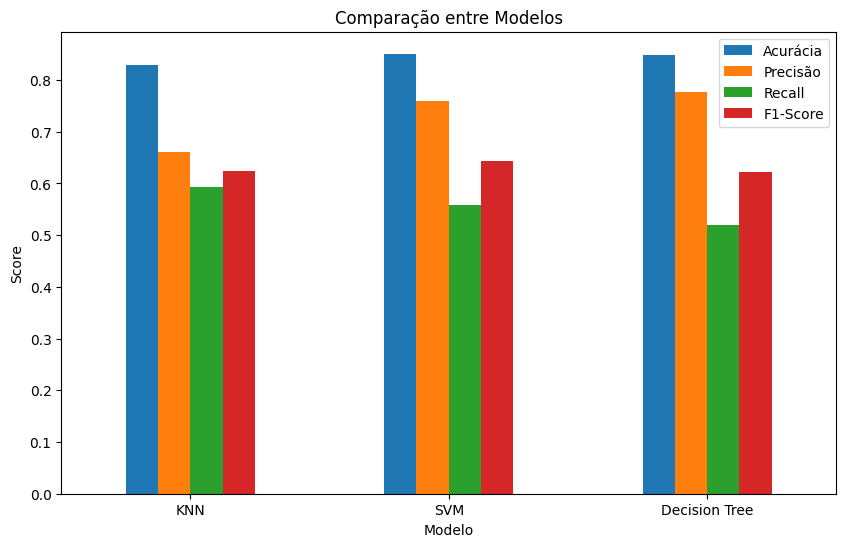

In [35]:
# Gráfico comparativo

resultados.set_index('Modelo').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Comparação entre Modelos")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

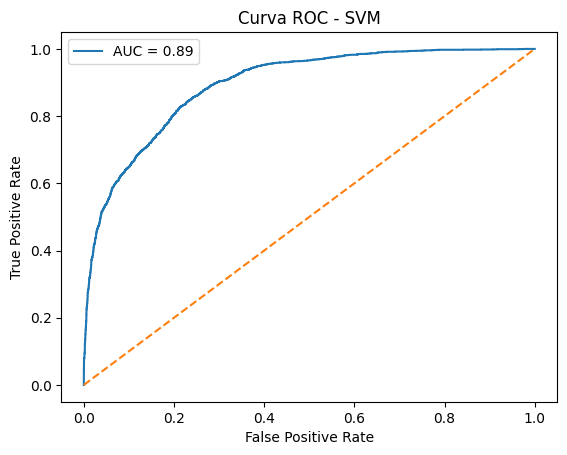

In [37]:
# Curva ROC SVM

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.plot(fpr_svm, tpr_svm, label=f'AUC = {roc_auc_svm:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.title("Curva ROC - SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

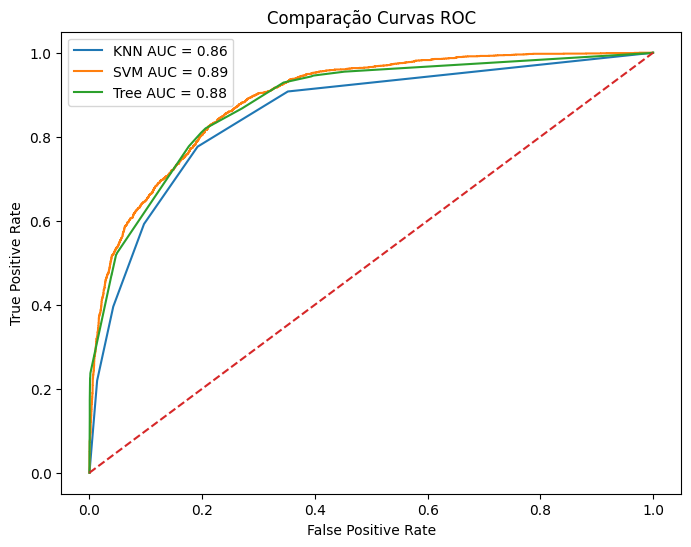

In [38]:
# =========================================
# 9. COMPARAÇÃO DAS CURVAS ROC
# =========================================

plt.figure(figsize=(8,6))

plt.plot(fpr_knn, tpr_knn, label=f'KNN AUC = {roc_auc_knn:.2f}')
plt.plot(fpr_svm, tpr_svm, label=f'SVM AUC = {roc_auc_svm:.2f}')
plt.plot(fpr_tree, tpr_tree, label=f'Tree AUC = {roc_auc_tree:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.title("Comparação Curvas ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# =========================================
# 10. CONCLUSÃO FINAL
# =========================================

Conclusão:

O modelo SVM apresentou o melhor equilíbrio entre
precisão, recall e F1-score, demonstrando melhor
capacidade de generalização.

O KNN apresentou bom desempenho, porém maior
sensibilidade à escala dos dados.

A Árvore de Decisão foi o modelo mais interpretável,
mas apresentou tendência ao overfitting.

Assim, o SVM foi considerado o melhor modelo
para o problema de classificação de renda.